# Triage Prediction Pipeline - OOP Implementation

This notebook implements a complete triage prediction pipeline using Object-Oriented Programming principles.

## 1. Load Data

In [1]:
# Import necessary libraries and OOP modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import os
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="darkgrid")

# Import OOP modules
from modules.data_loader import load_data
from modules.preprocessing import *
from modules.visualization import *
from modules.models import ModelTrainer
from modules.evaluation import ModelEvaluator, ModelExporter
from modules.config import *
from sklearn.model_selection import train_test_split

In [33]:
# Load data using OOP DataLoader
chief_complaint_data, patient_history_data, train_data, test_data, sample_submission_data = load_data()
print(f"Train data shape: {train_data.shape}")
print(f"Test data shape: {test_data.shape}")

Train data shape: (80000, 66)
Test data shape: (20000, 63)


In [34]:
target_col = 'triage_acuity'
X = train_data.drop(columns=[target_col])
y = train_data[target_col]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, 
    test_size=TEST_SIZE,  # 20% for validation+test
    random_state=SEED,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=TEST_SIZE,  # Split 20% into 10% val, 10% test
    random_state=SEED,
    stratify=y_temp
)

In [35]:
# Reload modules to get latest changes
import importlib
import modules.visualization
importlib.reload(modules.visualization)
from modules.visualization import DataAnalysis, DataVisualizer

# Reinitialize objects with reloaded modules
data_analysis = DataAnalysis(train_data)
data_visualizer = DataVisualizer()

In [55]:
# Reload preprocessing module
import importlib
import modules.preprocessing
importlib.reload(modules.preprocessing)
from modules.preprocessing import NumericalPreprocessor, CategoricalPreprocessor, TextPreprocessor, FeatureBuilder

# Reload models module
import modules.models
importlib.reload(modules.models)
from modules.models import ModelTrainer

In [37]:
# Set environment seed for reproducible results
def seeder(seed):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

seeder(SEED)

## 2. Data Analysis and Visualization

In [38]:
# Initialize DataAnalysis and DataVisualizer
data_analysis = DataAnalysis(train_data)
data_visualizer = DataVisualizer()

In [8]:
# Analyze missing values
missing_analysis = data_analysis.analyze_missing_values()
print("Missing values analysis:")
print(missing_analysis)

Missing values analysis:
                                        column  missing_count  \
systolic_bp                        systolic_bp           4146   
diastolic_bp                      diastolic_bp           4146   
mean_arterial_pressure  mean_arterial_pressure           4146   
pulse_pressure                  pulse_pressure           4146   
shock_index                        shock_index           4146   
respiratory_rate              respiratory_rate           3067   
temperature_c                    temperature_c            574   

                        missing_percentage  
systolic_bp                           5.18  
diastolic_bp                          5.18  
mean_arterial_pressure                5.18  
pulse_pressure                        5.18  
shock_index                           5.18  
respiratory_rate                      3.83  
temperature_c                         0.72  


Saved figure: d:\Desktop\CADT\Year_2\Term2\OOP-Python\Project\modules\..\image\missing_values_heatmap.png


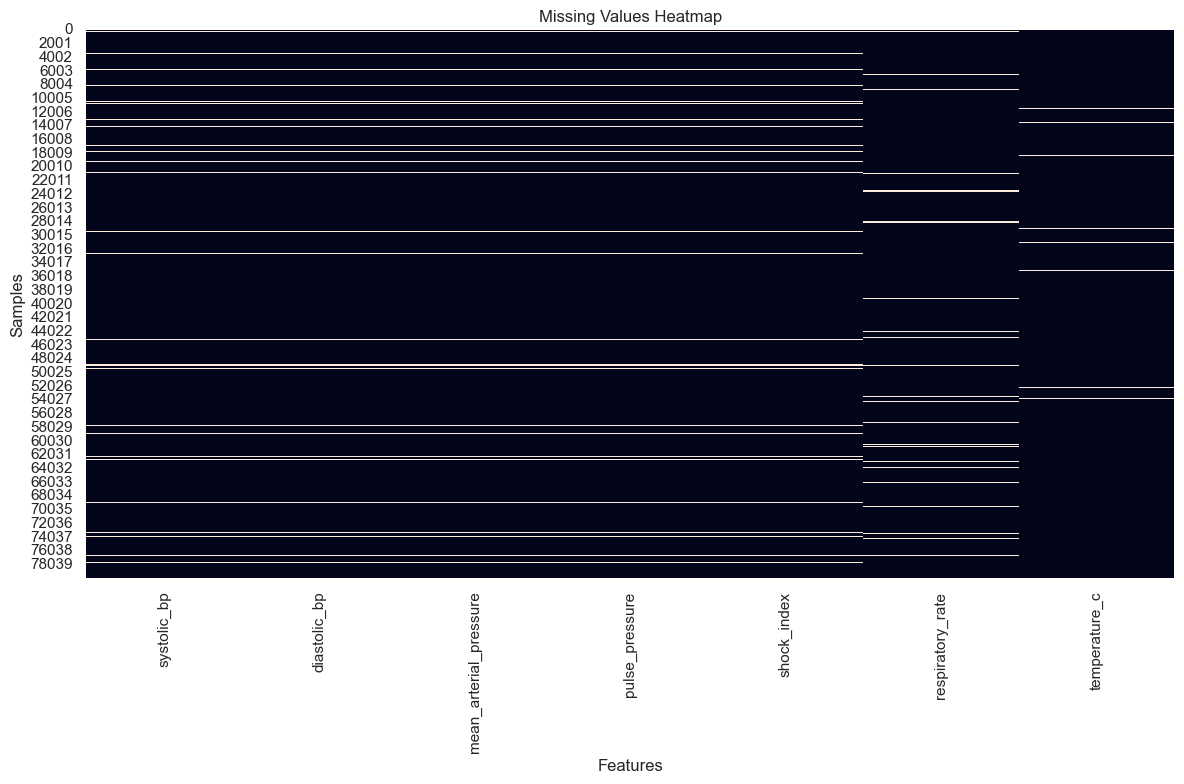


**Insight:** Missing values in groups (e.g., BP parameters) indicate that when blood pressure is missing, all related metrics are also missing. This suggests imputation strategies should consider these relationships.


In [ ]:
# Plot missing values heatmap
data_visualizer.plot(plot_type="missing_heatmap", data=train_data, missing_analysis=missing_analysis)

**Insight:** Missing values in groups (e.g., BP parameters) indicate that when blood pressure is missing, all related metrics are also missing. This means imputation strategies should consider these relationships.

Saved figure: d:\Desktop\CADT\Year_2\Term2\OOP-Python\Project\modules\..\image\target_distribution.png


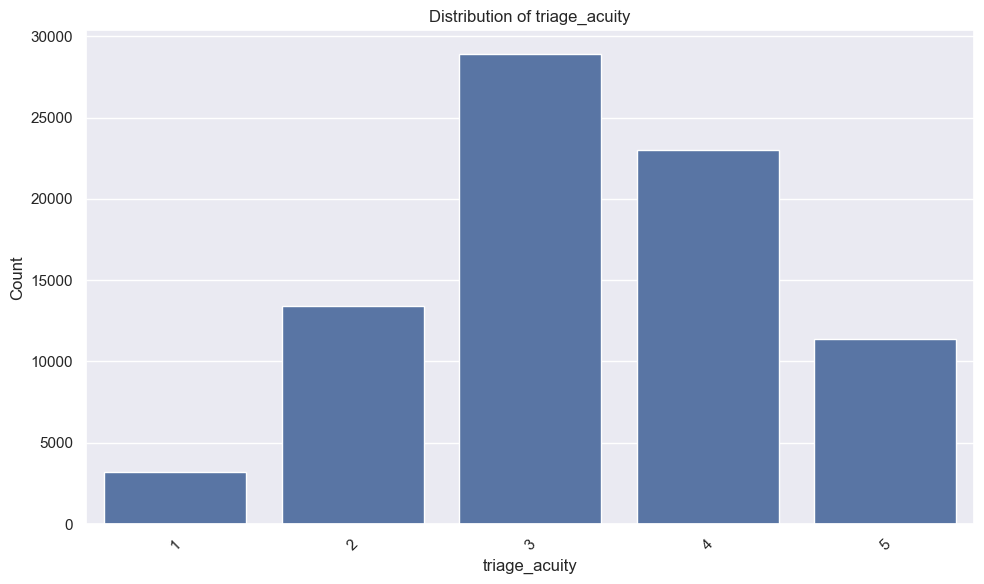


**Insight:** The target classes show imbalance with higher representation of less urgent cases. This justifies the use of SMOTE for oversampling to balance the classes during training.


In [ ]:
# Plot target distribution
data_visualizer.plot(plot_type="target_distribution", data=train_data, target_col=TARGET)

**Insight:** The target classes show imbalance with higher representation of less urgent cases. This justifies the use of SMOTE for oversampling to balance the classes during training.

In [11]:
# Analyze correlations
correlation_matrix = data_analysis.analyze_correlations(target_col=TARGET)
print("\nCorrelations with target:")
print(correlation_matrix)


Correlations with target:
                                triage_acuity
news2_score                         -0.814804
ed_los_hours                        -0.756714
respiratory_rate                    -0.652945
temperature_c                       -0.649193
shock_index                         -0.631830
pain_score                          -0.618834
heart_rate                          -0.567962
num_prior_ed_visits_12m             -0.564138
num_prior_admissions_12m            -0.311197
num_comorbidities                   -0.142150
num_active_medications              -0.094220
hx_hyperthyroidism                  -0.053749
hx_liver_disease                    -0.052915
hx_coagulopathy                     -0.051430
hx_anxiety                          -0.051357
hx_immunosuppressed                 -0.050834
hx_asthma                           -0.050180
hx_diabetes_type1                   -0.049388
hx_hiv                              -0.048820
hx_epilepsy                         -0.048331
hx_mali

Saved figure: d:\Desktop\CADT\Year_2\Term2\OOP-Python\Project\modules\..\image\correlation_heatmap.png


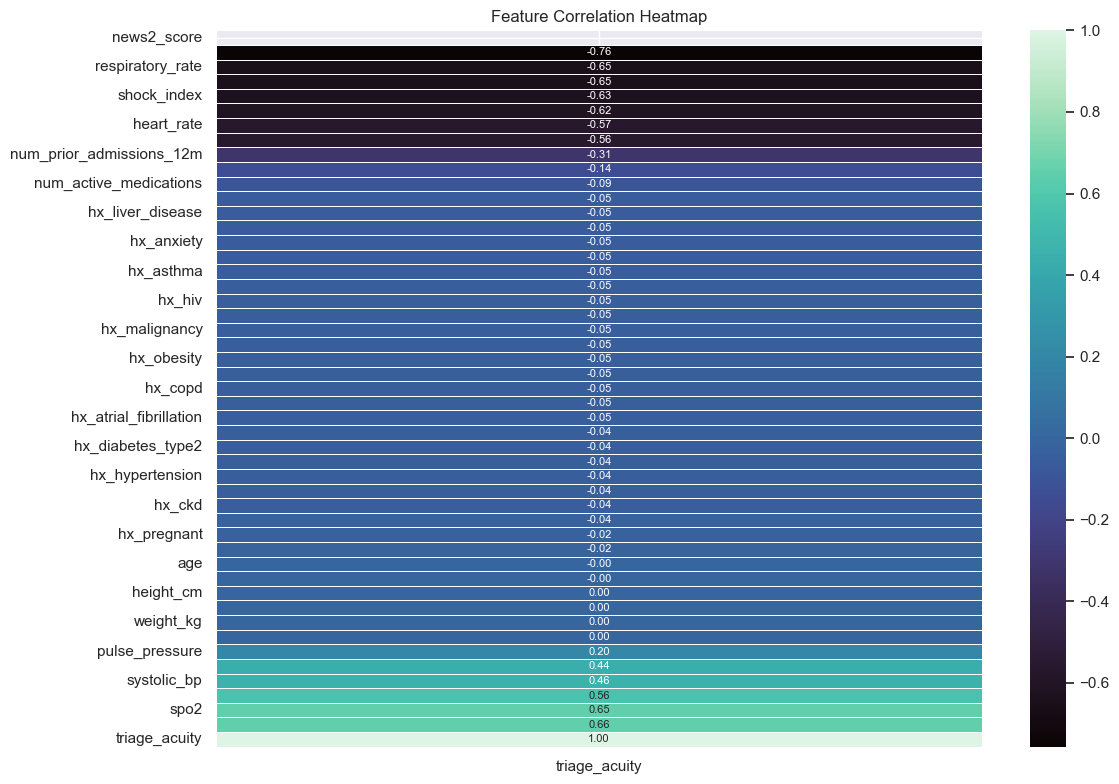


**Insight:** Features like 'news2_score' and 'shock_index' show strong correlations with acuity level, validating their importance in triage decisions.


In [ ]:
# Plot correlation heatmap
data_visualizer.plot(plot_type="correlation_heatmap", correlation_matrix=correlation_matrix)

**Insight:** Features like 'news2_score' and 'shock_index' show strong correlations with acuity level, validating their importance in triage decisions.

Saved figure: d:\Desktop\CADT\Year_2\Term2\OOP-Python\Project\modules\..\image\numerical_distributions.png


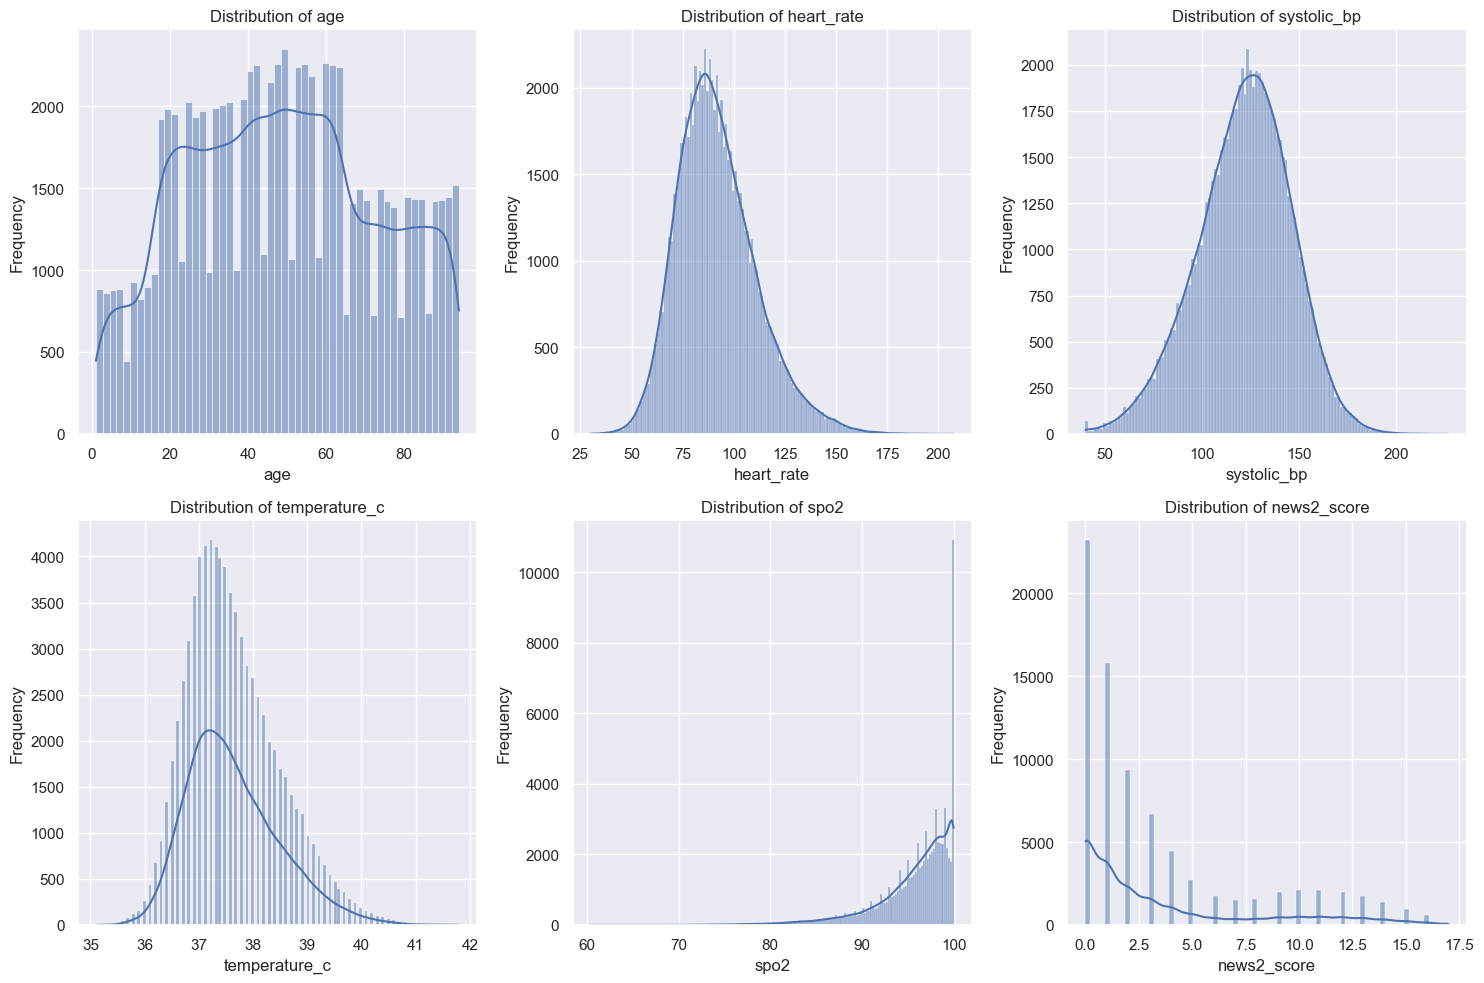


**Insight:** Numerical features show varying distributions. Features like 'news2_score' have right-skewed distributions typical of medical scoring systems, justifying the use of StandardScaler for normalization.


In [ ]:
# Plot numerical distributions
key_numerical_cols = ['age', 'heart_rate', 'systolic_bp', 'temperature_c', 'spo2', 'news2_score']
data_visualizer.plot(plot_type="numerical_distributions", data=train_data, num_cols=key_numerical_cols)

**Insight:** Numerical features show varying distributions. Features like 'news2_score' have right-skewed distributions typical of medical scoring systems, justifying the use of StandardScaler for normalization.

In [14]:
# Initialize PatientHistoryDataVisualizer
patient_history_visualizer = PatientHistoryDataVisualizer(patient_history_data)

In [15]:
# Analyze patient history conditions
condition_counts = patient_history_visualizer.analyze()

CONDITION ANALYSIS

Most common condition:  hx_coronary_artery_disease
Least common condition: hx_pregnant

Top 5 conditions:
hx_coronary_artery_disease    28182
hx_atrial_fibrillation        28149
hx_ckd                        28142
hx_heart_failure              28081
hx_hypertension               28067
dtype: int64


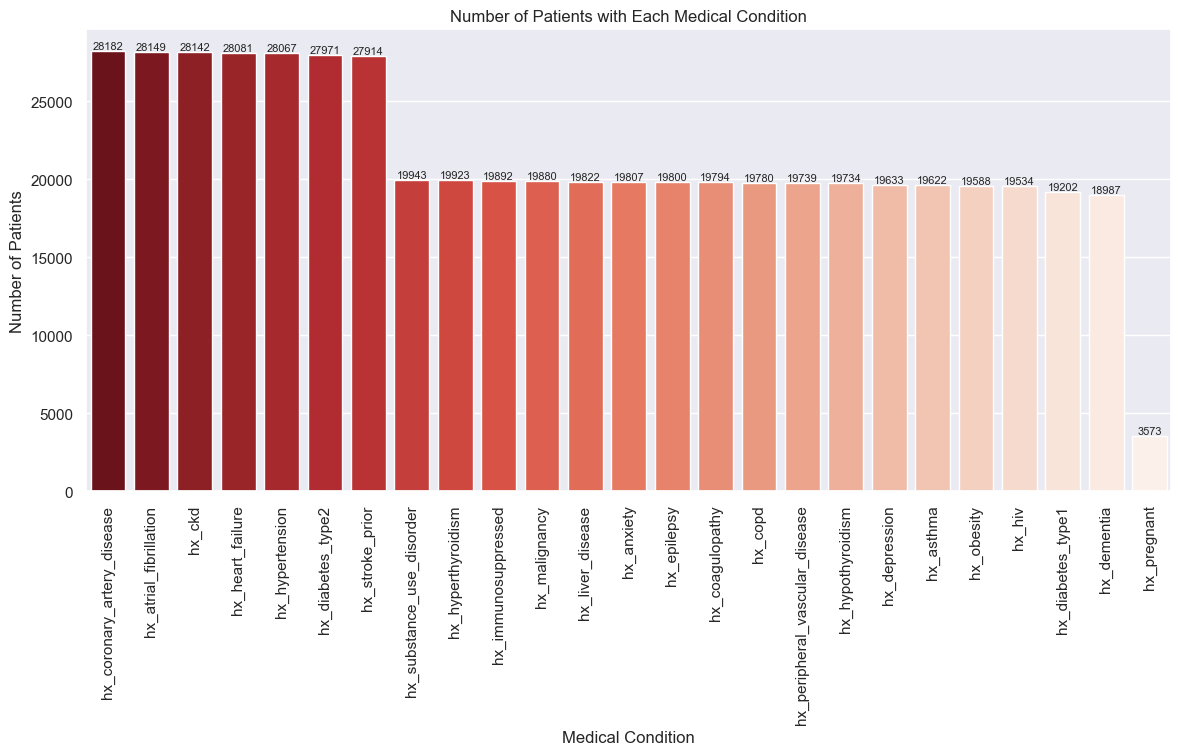

In [16]:
# Plot condition counts
patient_history_visualizer.plot(plot_type="condition_counts")

From the bar chart, hx_hypertension has the highest patient count making it the most common condition in this dataset. This suggests that cardiovascular conditions are the most prevalent among emergency room patients

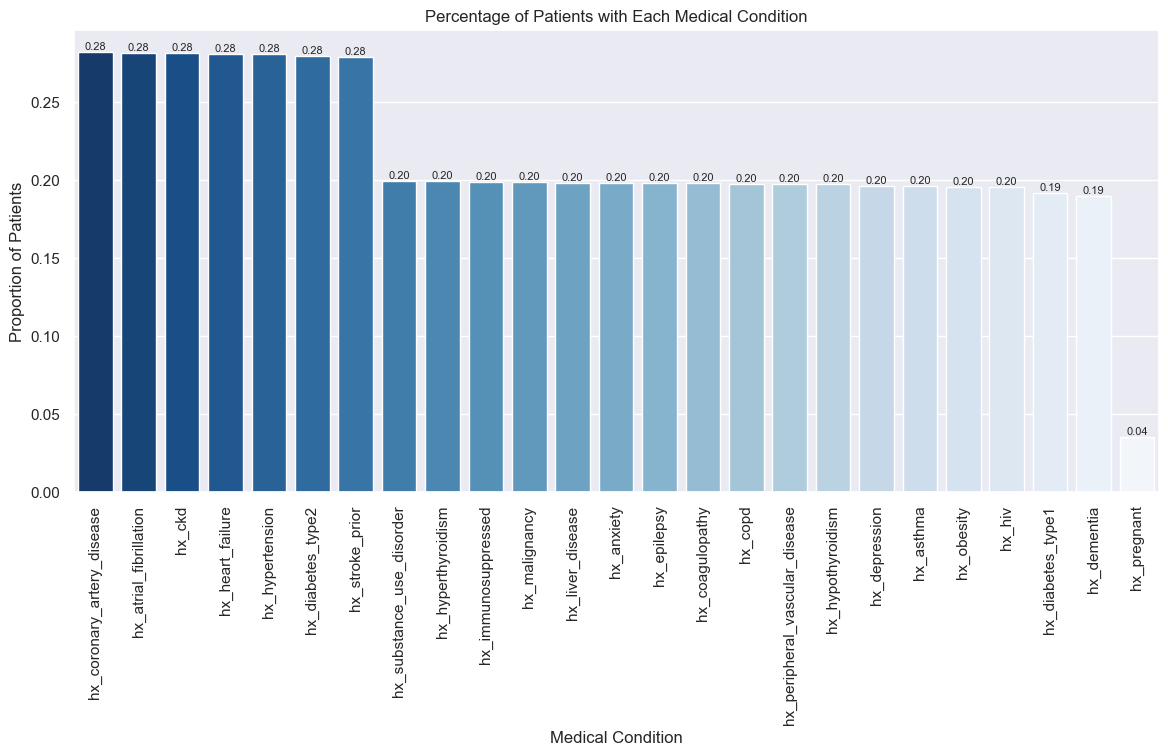

In [17]:
# Plot condition percentages
patient_history_visualizer.plot(plot_type="condition_percentages")

From the percentage chart, the difference between conditions is consistent from one condition to another, suggesting a balanced construction of the dataset. Majority of patients carry at least one chronic condition when arriving at the emergency room.

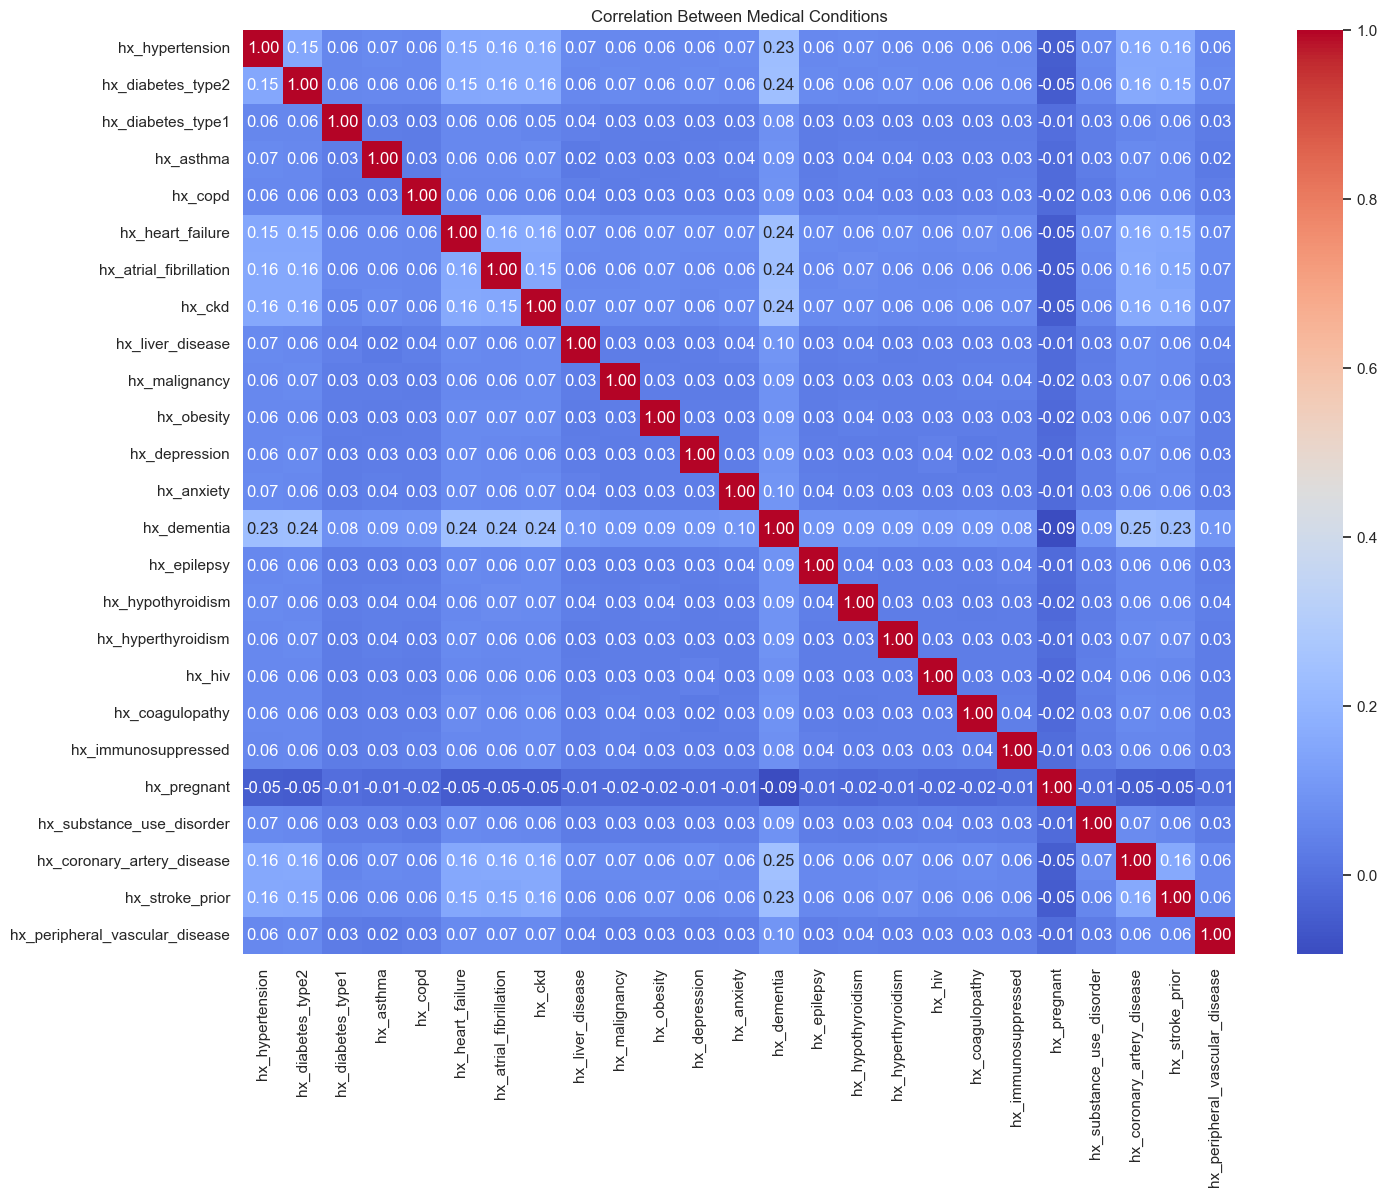

In [18]:
# Plot condition correlations
patient_history_visualizer.plot(plot_type="condition_correlations")

From the heatmap, most medical conditions show very low correlation with each other (close to 0.00), meaning they appear independently. However a few condition pairs show slightly higher correlation, suggesting certain diseases tend to co-exist in the same patients

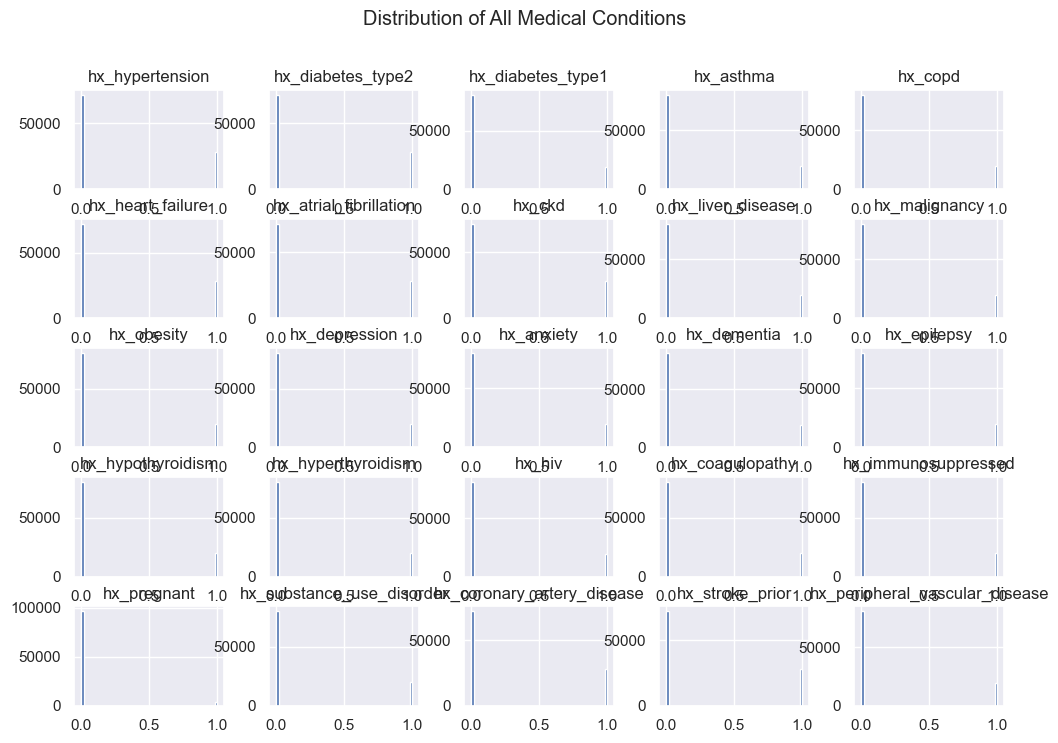

In [19]:
patient_history_visualizer.plot(plot_type="distribution_medical_condition")

From the histogram, all conditions show a clear binary distribution concentrated at 0 and 1. This confirms the dataset is correctly formatted as binary medical history data with no unusual distributions detected.

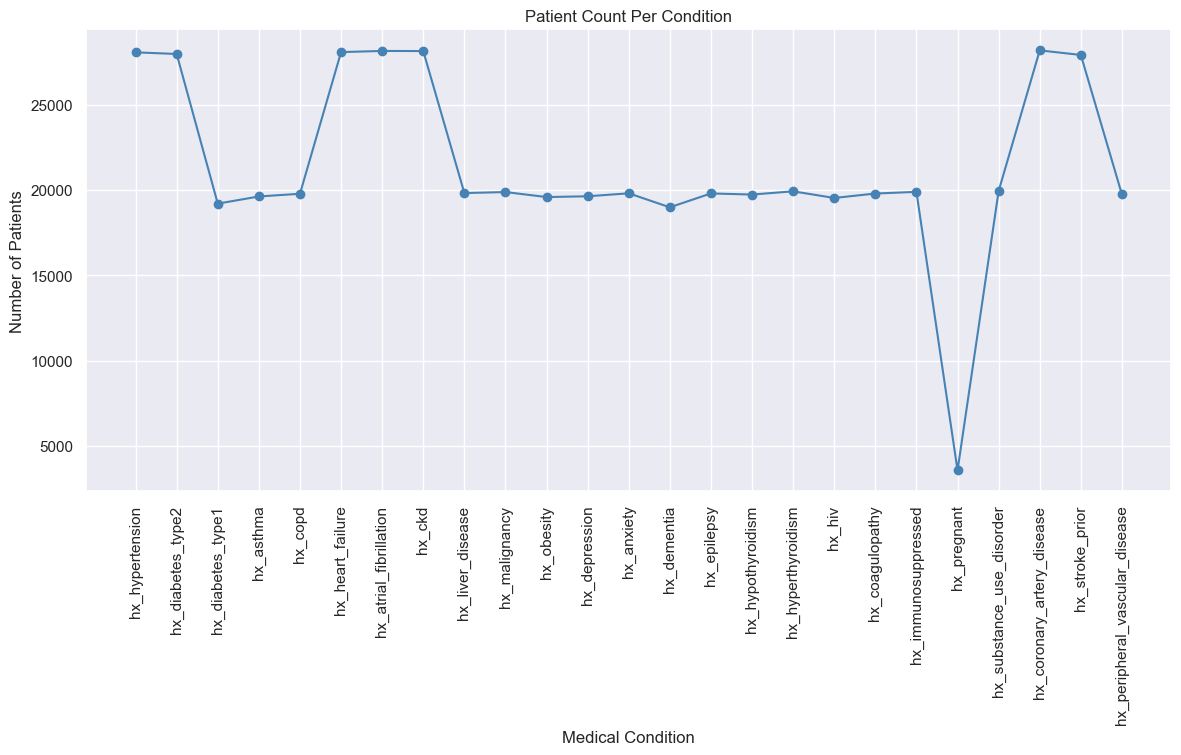

In [20]:
patient_history_visualizer.plot(plot_type="conditions_per_patients")

From the line chart, patient count across conditions is uneven with some conditions spiking significantly higher. This confirms that certain chronic conditions are far more common in emergency patients and should be given higher priority weight in the triage prediction model.

### Text Analysis and visualization

In [21]:
# Initialize TextDataVisualizer
text_visualizer = TextDataVisualizer(chief_complaint_data)

In [22]:
# Analyze text lengths
text_stats = text_visualizer.analyze_text_lengths()

TEXT LENGTH ANALYSIS
mean_length: 39.68
median_length: 39.00
min_length: 7.00
max_length: 77.00
std_length: 9.84


Saved figure: d:\Desktop\CADT\Year_2\Term2\OOP-Python\Project\modules\..\image\text_length_distribution.png


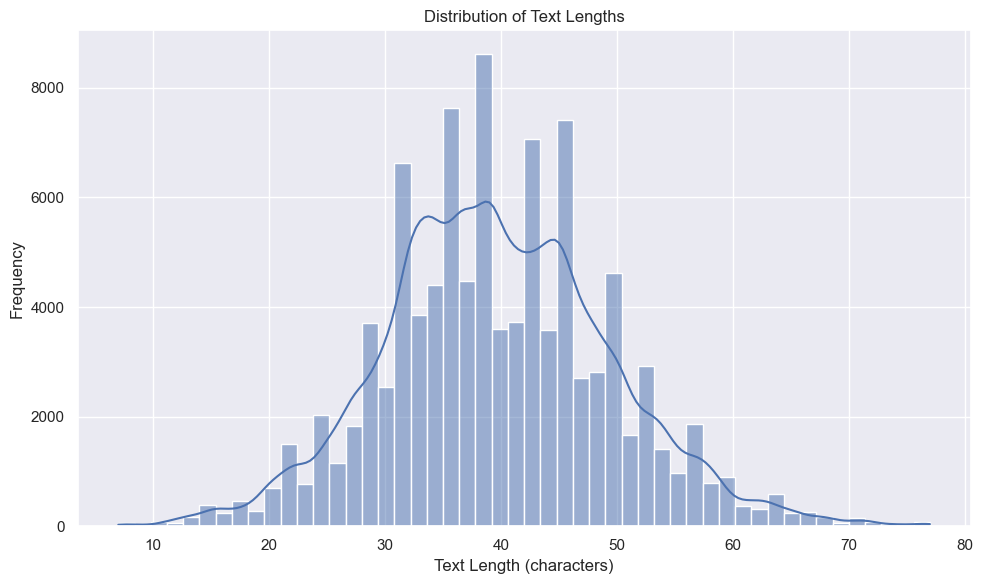

In [23]:
# Plot text length distribution
text_visualizer.plot(plot_type="text_length_distribution")

Insight: Text lengths vary significantly. Very short complaints might need different preprocessing than longer ones. This suggests using adaptive text preprocessing strategies or separate handling for brief vs detailed complaints.

Saved figure: d:\Desktop\CADT\Year_2\Term2\OOP-Python\Project\modules\..\image\word_count_distribution.png


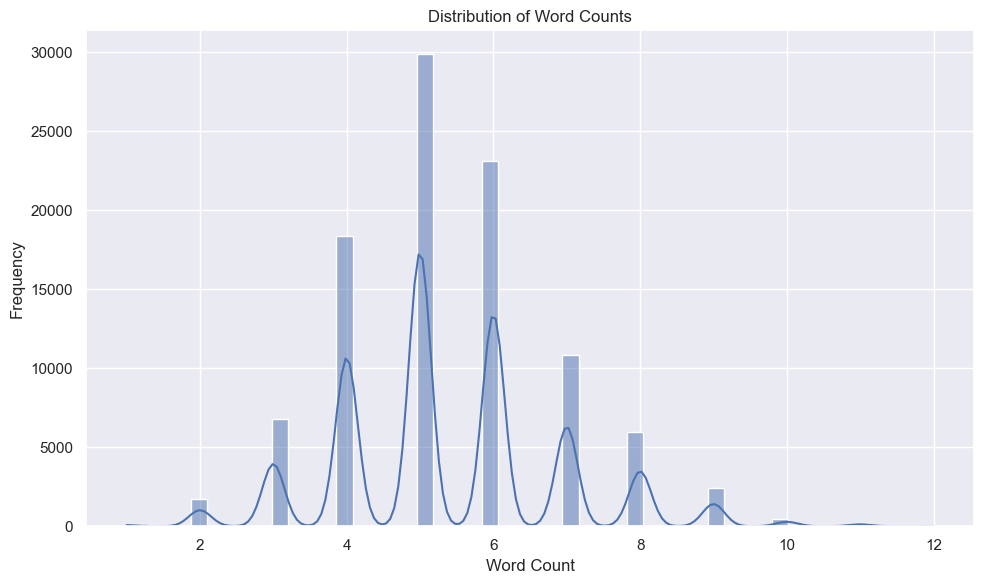

In [24]:
# Plot word count distribution
text_visualizer.plot(plot_type="word_count_distribution")

Most units (e.g., sentences or texts) have a relatively low word count, probably peaking somewhere between 2 and 6 words, given that the frequency is very high in that range. This shows how often each word count occurs, with frequencies ranging up to 30,000.

Saved figure: d:\Desktop\CADT\Year_2\Term2\OOP-Python\Project\modules\..\image\common_words.png


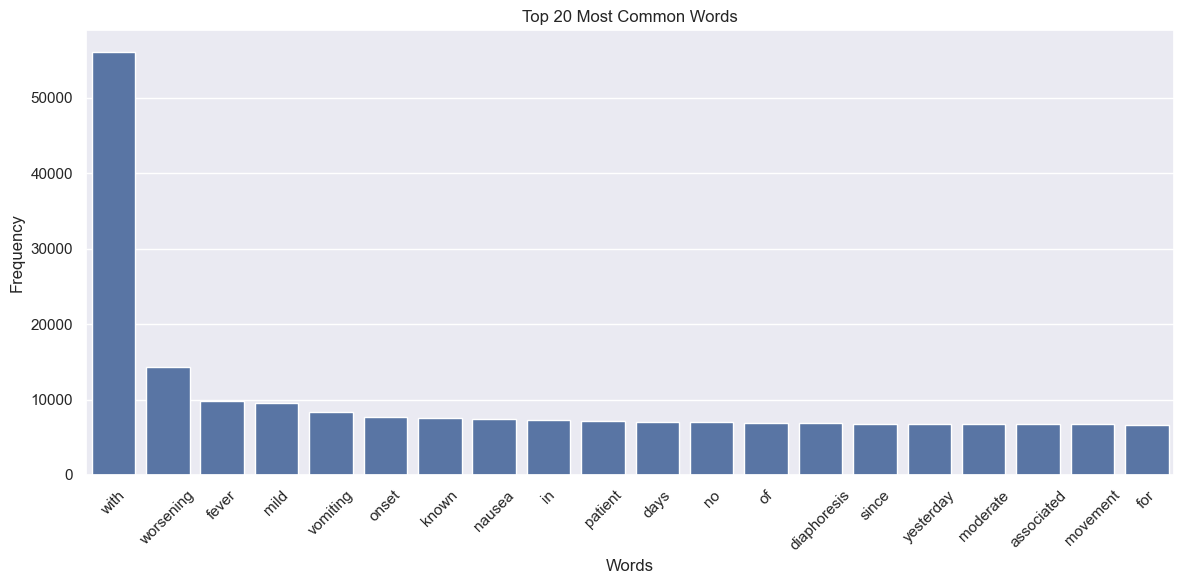

In [25]:
# Plot common words
text_visualizer.plot(plot_type="common_words")

Insight: Common medical terms dominate the vocabulary. Stop word removal and domain-specific preprocessing will be crucial. The presence of medical jargon suggests TF-IDF with custom vocabulary might be more effective than generic text processing.

Saved figure: d:\Desktop\CADT\Year_2\Term2\OOP-Python\Project\modules\..\image\text_length_by_category.png


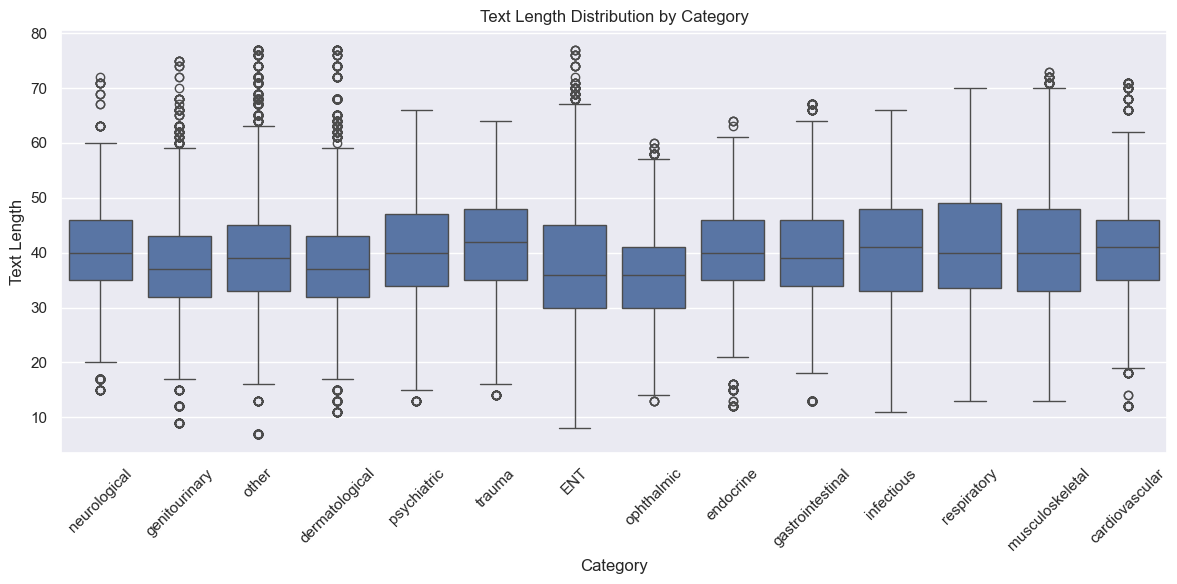

In [26]:
# Plot text length by category
text_visualizer.plot(plot_type="text_length_by_category")

Insight: Different complaint categories have varying text lengths. This indicates that preprocessing should consider complaint type - neurological complaints might need different text processing than dermatological ones.

Overall Insights:
- **Missing Values:** Grouped missing patterns in vital signs suggest multivariate imputation
- **Class Imbalance:** SMOTE needed for target balancing
- **Feature Correlations:** Strong medical score correlations validate feature importance
- **Patient History:** Condition correlations suggest feature engineering opportunities
- **Text Data:** Variable lengths and medical terminology require specialized preprocessing

**Preprocessing Strategy:**
1. Handle missing values with imputation
2. Scale numerical features with outlier clipping
3. Encode categorical features appropriately
4. Process text with medical-aware TF-IDF and ESI_WORD_DICT
5. Engineer features from patient history correlations
6. Apply SMOTE for class balancing

## 3. Data Preprocessing

In [50]:
# Initialize preprocessors
numerical_preprocessor = NumericalPreprocessor()
categorical_preprocessor = CategoricalPreprocessor()
text_preprocessor = TextPreprocessor(text_col='chief_complaint_raw')

# Create feature builder with all preprocessors
preprocessors = [numerical_preprocessor, text_preprocessor]
feature_builder = FeatureBuilder(preprocessors)

In [40]:
# Check unique values in y_train
print("Unique values in y_train:", np.unique(y_train))

Unique values in y_train: [1 2 3 4 5]


In [41]:
cat_cols = train_data.select_dtypes(include='object').columns
for col in cat_cols:
    if col not in LEAKAGE_COLS:
        print(f"{col}: {train_data[col].nunique()} unique values")

site_id: 5 unique values
triage_nurse_id: 50 unique values
arrival_mode: 6 unique values
arrival_day: 7 unique values
arrival_season: 4 unique values
shift: 4 unique values
age_group: 4 unique values
sex: 3 unique values
language: 8 unique values
insurance_type: 5 unique values
transport_origin: 7 unique values
pain_location: 9 unique values
mental_status_triage: 5 unique values
chief_complaint_system: 14 unique values
chief_complaint_raw: 4949 unique values


In [51]:
# Build features using OOP pipeline
X_train_features = feature_builder.build(X_train)
X_val_features = feature_builder.build(X_val)
X_test_features = feature_builder.build(X_test)

print(f"Training features shape: {X_train_features.shape}")
print(f"Validation features shape: {X_val_features.shape}")
print(f"Test features shape: {X_test_features.shape}")

Training features shape: (64000, 149)
Validation features shape: (12800, 149)
Test features shape: (3200, 149)


In [44]:
# Check unique values in y_train_processed
print("Unique values in y_train_processed:", np.unique(y_val))

Unique values in y_train_processed: [1 2 3 4 5]


## 4. Machine Learning

In [52]:
# Apply class balance to training set
smote = ClassImbalanceHandler(SMOTE_K_NEIGHBORS, random_state=SEED)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_features, y_train)
print(f"Original training set shape: {X_train_features.shape}")
print(f"Resampled training set shape: {X_train_balanced.shape}")

Original training set shape: (64000, 149)
Resampled training set shape: (115685, 149)


In [57]:
# Initialize and train models
model_trainer = ModelTrainer()
trained_models = model_trainer.train_models(X_train_balanced, y_train_balanced)
print("Trained models:", list(trained_models.keys()))
# trainer = ModelTrainer()
# trainer.models['XGBoost'].fit(X_train_balanced, y_train_balanced)
# xgb = trainer.models['XGBoost']

# metrics = xgb.evaluate(X_val_features, y_val)
# print(metrics)

Training Logistic Regression...
Training Random Forest...
Training XGBoost...
Trained models: ['Logistic Regression', 'Random Forest', 'XGBoost']


## 5. Model Evaluation and Comparison

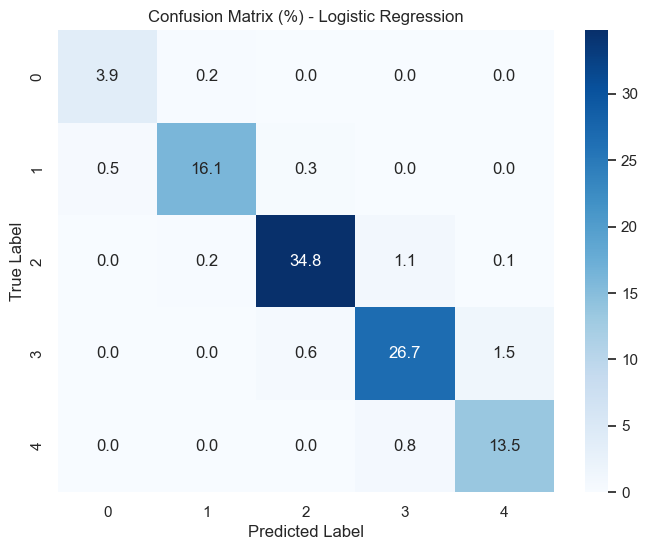

Classification Report for Logistic Regression:
              precision    recall  f1-score   support

           1       0.90      0.96      0.93       515
           2       0.98      0.96      0.97      2151
           3       0.98      0.96      0.97      4627
           4       0.94      0.93      0.93      3683
           5       0.90      0.95      0.92      1824

    accuracy                           0.95     12800
   macro avg       0.94      0.95      0.94     12800
weighted avg       0.95      0.95      0.95     12800



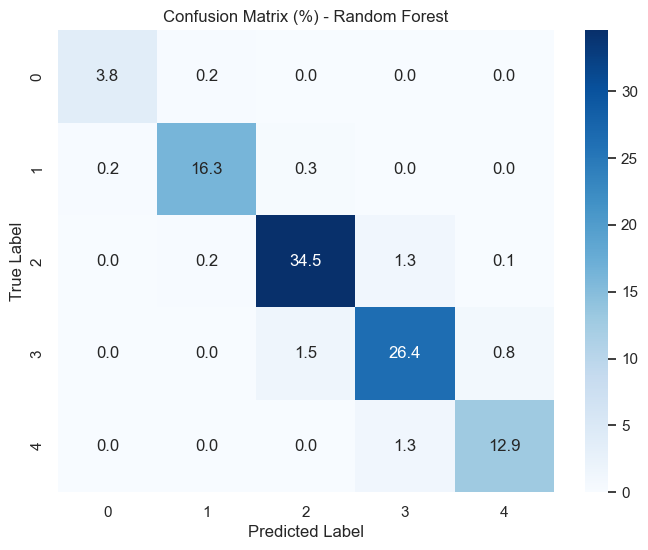

Classification Report for Random Forest:
              precision    recall  f1-score   support

           1       0.95      0.94      0.95       515
           2       0.97      0.97      0.97      2151
           3       0.95      0.96      0.95      4627
           4       0.91      0.92      0.91      3683
           5       0.94      0.91      0.92      1824

    accuracy                           0.94     12800
   macro avg       0.94      0.94      0.94     12800
weighted avg       0.94      0.94      0.94     12800



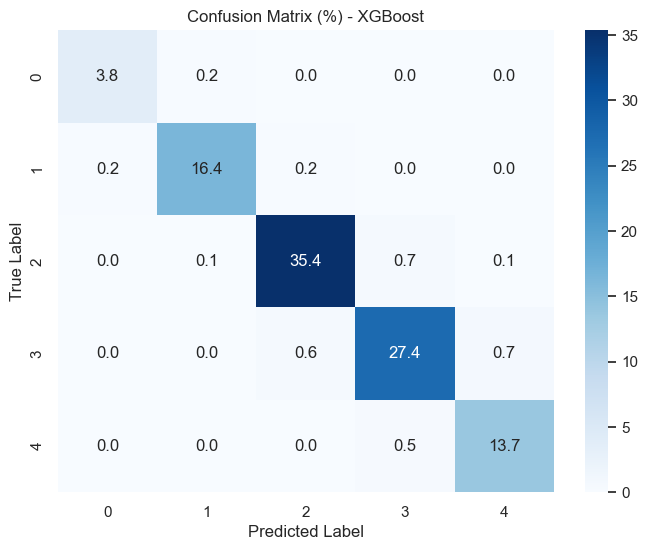

Classification Report for XGBoost:
              precision    recall  f1-score   support

           1       0.96      0.95      0.95       515
           2       0.98      0.98      0.98      2151
           3       0.98      0.98      0.98      4627
           4       0.96      0.95      0.96      3683
           5       0.95      0.96      0.95      1824

    accuracy                           0.97     12800
   macro avg       0.96      0.96      0.96     12800
weighted avg       0.97      0.97      0.97     12800


Model Evaluation Results:
                 Model  Accuracy  Precision    Recall  F1-Score
0  Logistic Regression  0.948906   0.949654  0.948906  0.949100
1        Random Forest  0.940312   0.940388  0.940312  0.940306
2              XGBoost  0.967656   0.967710  0.967656  0.967668


In [58]:
# Evaluate models using OOP ModelEvaluator
model_evaluator = ModelEvaluator()
evaluation_results = model_evaluator.evaluate_models(trained_models, X_val_features, y_val)
print("\nModel Evaluation Results:")
print(evaluation_results)

## 6. Export Best Model

In [59]:
# Export best model using OOP ModelExporter
model_exporter = ModelExporter()
exported_path = model_exporter.export_best_model(trained_models, evaluation_results, metric='F1-Score')
print(f"\nBest model exported to: {exported_path}")

Exported best model 'XGBoost' (Score: 0.9677) to output\best_model_ranked.pkl

Best model exported to: output\best_model_ranked.pkl
